# Comparing model classification

This notebook demonstrates differences in the discriminative power of model attractor characterization using two properties:

1. **Dynamic properties** (via MaBoSS simulation)
2. **Network properties** (via edge-based feature comparison)

We compute distance matrices from both approaches and visualize them with clustermaps to compare how each method groups models according to their attractor sets.

As an example, we use the model `Death Receptor Signaling_20221256` from Kadelka et al. (2024).

In [1]:
import pandas as pd 
import os
import sys
sys.path.append('/home/spankaew/Git/Git_Curie/AstroLogics/src')
import astrologics as ast
import seaborn as sns
import matplotlib.pyplot as plt

os.chdir('/home/spankaew/Git/Git_Curie/AstroLogics')

# Load the model's attractor groups

In [ ]:
# Load the precomputed attractor groups for this model
attractor_group = pd.read_csv('./data/attractor_group/attractor_group/Death Receptor Signaling_20221256_attractor_group.csv', index_col=0)

# Model clustering via dynamic properties

In this section, we focus on dynamic model properties by running MaBoSS simulations for each model in the ensemble. We then compute pairwise model distances using DTW and compile the results into a distance matrix.

In [27]:
# Load the model path and create AstroLogics object
model_path = './inferred_model/Death Receptor Signaling_20221256/'
model = ast.ensemble(model_path, project_name = 'DeathReceptorSignaling')
model.create_simulation()

Simulation object created


We run simulations with the following parameters:

In [28]:
# Configure simulation parameters
model.simulation.update_parameters(max_time = 15, sample_count = 1000)
model.simulation.run_simulation()

Start simulation


  0%|          | 0/1000 [00:00<?, ?it/s]

Simulation completed


We compute the distance matrix using the full trajectory.

In [29]:
model.create_trajectory()
model.trajectory.calculate_distancematrix(mode = 'trajectory')

Trajectory object created
Calculating distance matrix for whole trajectory...


  0%|          | 0/1000 [00:00<?, ?it/s]

Distance matrix calculated successfully.


Finally, we plot the distance matrix as a clustermap. Row and column colors indicate each model's attractor group.

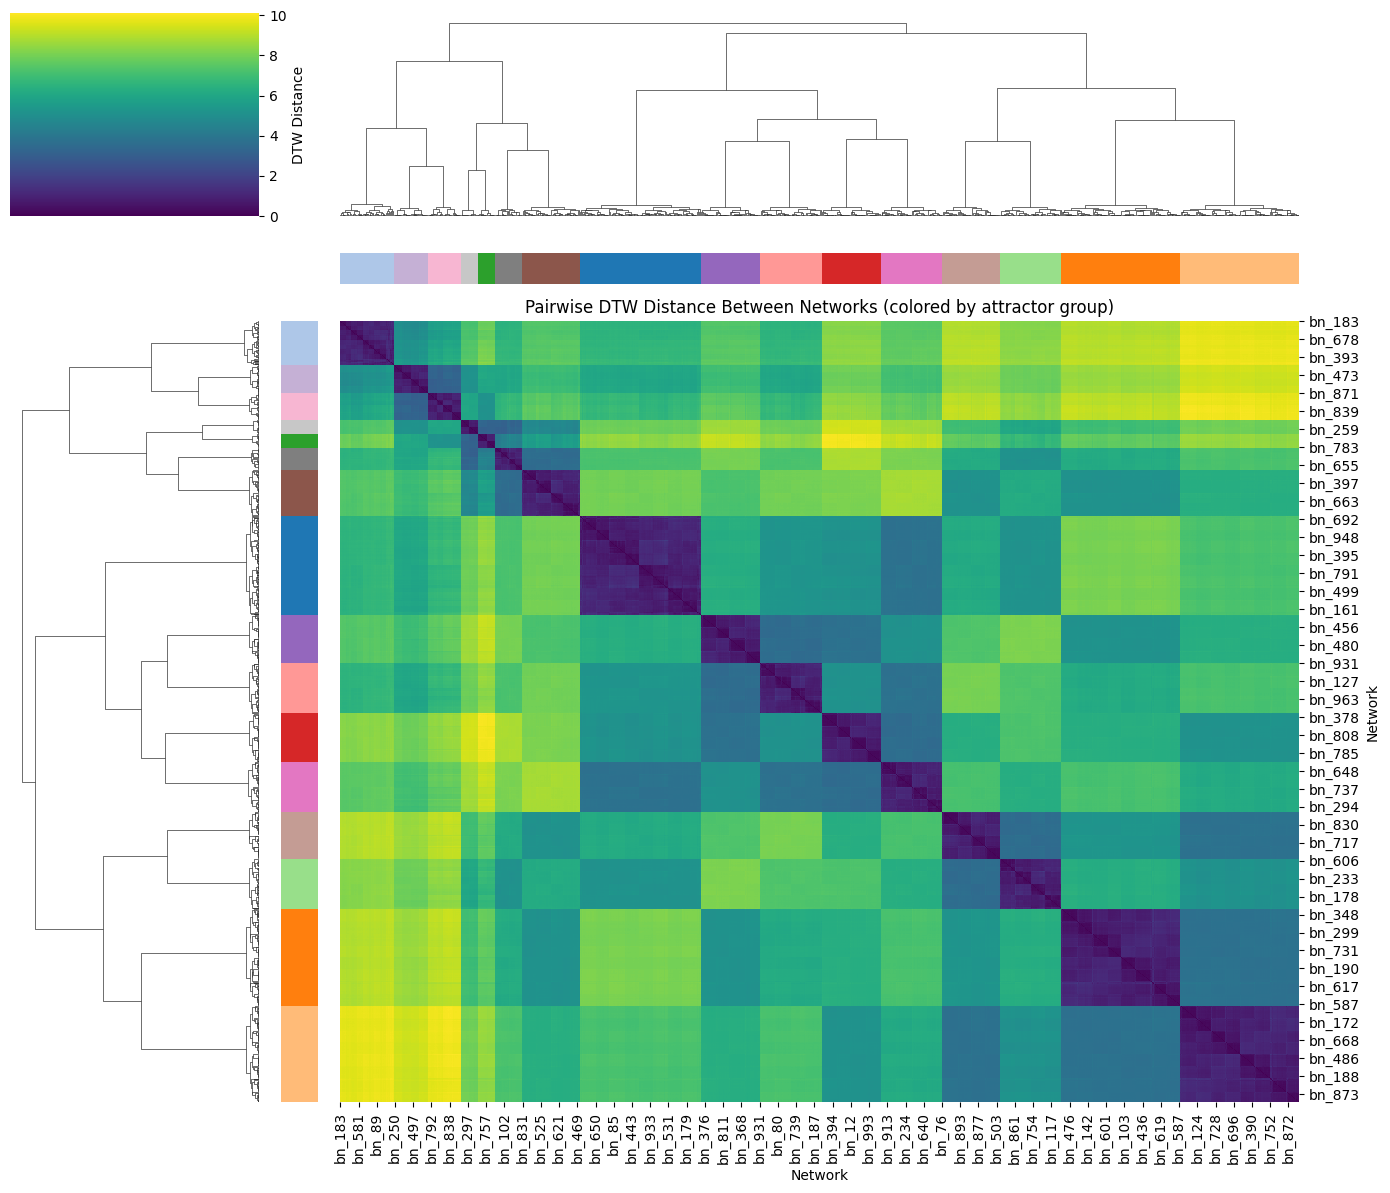

In [ ]:
# Prepare row and column colors based on `attractor_group`
# Create a color mapping for each unique group
unique_groups = attractor_group.iloc[:, 0].unique()
colors = plt.cm.tab20(range(len(unique_groups)))
group_color_map = {group: colors[i] for i, group in enumerate(unique_groups)}

# Load the DTW distance matrix
df_dtw_series = model.trajectory.distance_matrix

# Create row and column color vectors
row_colors = [group_color_map[attractor_group.loc[idx, attractor_group.columns[0]]] 
              for idx in df_dtw_series.index if idx in attractor_group.index]
col_colors = row_colors  # Same colors for columns because the matrix is symmetric

# Create a clustermap visualization with attractor-group colors
g = sns.clustermap(df_dtw_series, cmap='viridis', annot=False, 
                   cbar_kws={'label': 'DTW Distance'},
                   row_colors=row_colors, col_colors=col_colors,
                   figsize=(14, 12))
g.ax_heatmap.set_title('Pairwise DTW Distance Between Networks (colored by attractor group)')
g.ax_heatmap.set_xlabel('Network')
g.ax_heatmap.set_ylabel('Network')
plt.tight_layout()
plt.show()

# Model clustering via network properties

In this section, we compute model distances based on network properties (edge-based features). We convert each model's edge features into a vector, compute pairwise distances using the Hamming metric, and compile the results into a distance matrix.

In [ ]:
from pathlib import Path
import sys

module_dir = Path('/home/spankaew/Git/Git_Curie/AstroLogics/scripts/Results_Supplementary_Analysis_x')
if str(module_dir) not in sys.path:
    sys.path.append(str(module_dir))

from logic_network_utils import (
    load_models_from_folder,
    pairwise_hamming_matrix,
)

## Load all models from the folder

In [ ]:
# Load models from the inferred_model folder
model_folder = './inferred_model/Death Receptor Signaling_20221256/'
network_series = load_models_from_folder(model_folder)

print(f"\n{network_series}")
print(f"Loaded {len(network_series)} networks")

# Normalize all networks to use common nodes
print("\n--- Normalizing Networks ---")
network_series.normalize_to_common_nodes()

# Validate that all vectors have the same size
print("\n--- Validation ---")
network_series.validate_uniform_size()


Found 1000 model(s) in ./inferred_model/Death Receptor Signaling_20221256/
  ✓ Loaded: bn_0.bnet (29 nodes, 841 edges)
  ✓ Loaded: bn_1.bnet (30 nodes, 900 edges)
  ✓ Loaded: bn_10.bnet (29 nodes, 841 edges)
  ✓ Loaded: bn_100.bnet (30 nodes, 900 edges)
  ✓ Loaded: bn_101.bnet (29 nodes, 841 edges)
  ✓ Loaded: bn_102.bnet (30 nodes, 900 edges)
  ✓ Loaded: bn_103.bnet (30 nodes, 900 edges)
  ✓ Loaded: bn_104.bnet (30 nodes, 900 edges)
  ✓ Loaded: bn_105.bnet (29 nodes, 841 edges)
  ✓ Loaded: bn_106.bnet (30 nodes, 900 edges)
  ✓ Loaded: bn_107.bnet (30 nodes, 900 edges)
  ✓ Loaded: bn_108.bnet (30 nodes, 900 edges)
  ✓ Loaded: bn_109.bnet (29 nodes, 841 edges)
  ✓ Loaded: bn_11.bnet (30 nodes, 900 edges)
  ✓ Loaded: bn_110.bnet (30 nodes, 900 edges)
  ✓ Loaded: bn_111.bnet (30 nodes, 900 edges)
  ✓ Loaded: bn_112.bnet (30 nodes, 900 edges)
  ✓ Loaded: bn_113.bnet (29 nodes, 841 edges)
  ✓ Loaded: bn_114.bnet (30 nodes, 900 edges)
  ✓ Loaded: bn_115.bnet (30 nodes, 900 edges)
  ✓ Loaded:

True

## Compute Hamming distances between models based on edge-based features

In [ ]:
# Extract normalized feature matrices from network_series
networks_matrices = network_series.feature_matrices

# Compute pairwise distances using different methods
D_hamming_series = pairwise_hamming_matrix(
    [m.values for m in networks_matrices],
    method="hamming"
)

D_weighted_series = pairwise_hamming_matrix(
    [m.values for m in networks_matrices],
    method="weighted"
)

D_normalized_series = pairwise_hamming_matrix(
    [m.values for m in networks_matrices],
    method="normalized"
)

print(f"Pairwise Distance Matrix Shape: {D_hamming_series.shape}")
print(f"Number of networks compared: {D_hamming_series.shape[0]}")

# Convert to DataFrame for better visualization
df_hamming_series = pd.DataFrame(
    D_hamming_series,
    index=[Path(f).stem for f in network_series.filenames],
    columns=[Path(f).stem for f in network_series.filenames]
)

print(f"\nHamming Distance Matrix:\n{df_hamming_series}")


Pairwise Distance Matrix Shape: (1000, 1000)
Number of networks compared: 1000

Hamming Distance Matrix:
        bn_0  bn_1  bn_10  bn_100  bn_101  bn_102  bn_103  bn_104  bn_105  \
bn_0     0.0   2.0    0.0     4.0     6.0     2.0     4.0     2.0     0.0   
bn_1     2.0   0.0    2.0     6.0     4.0     4.0     2.0     4.0     2.0   
bn_10    0.0   2.0    0.0     4.0     6.0     2.0     4.0     2.0     0.0   
bn_100   4.0   6.0    4.0     0.0     2.0     2.0     4.0     2.0     4.0   
bn_101   6.0   4.0    6.0     2.0     0.0     4.0     2.0     4.0     6.0   
...      ...   ...    ...     ...     ...     ...     ...     ...     ...   
bn_995   2.0   0.0    2.0     6.0     4.0     4.0     2.0     4.0     2.0   
bn_996   2.0   4.0    2.0     2.0     4.0     4.0     6.0     0.0     2.0   
bn_997   2.0   4.0    2.0     2.0     4.0     4.0     6.0     0.0     2.0   
bn_998   0.0   2.0    0.0     4.0     6.0     2.0     4.0     2.0     0.0   
bn_999   0.0   2.0    0.0     4.0     6.0     2.

## Plot the resulting distance matrix

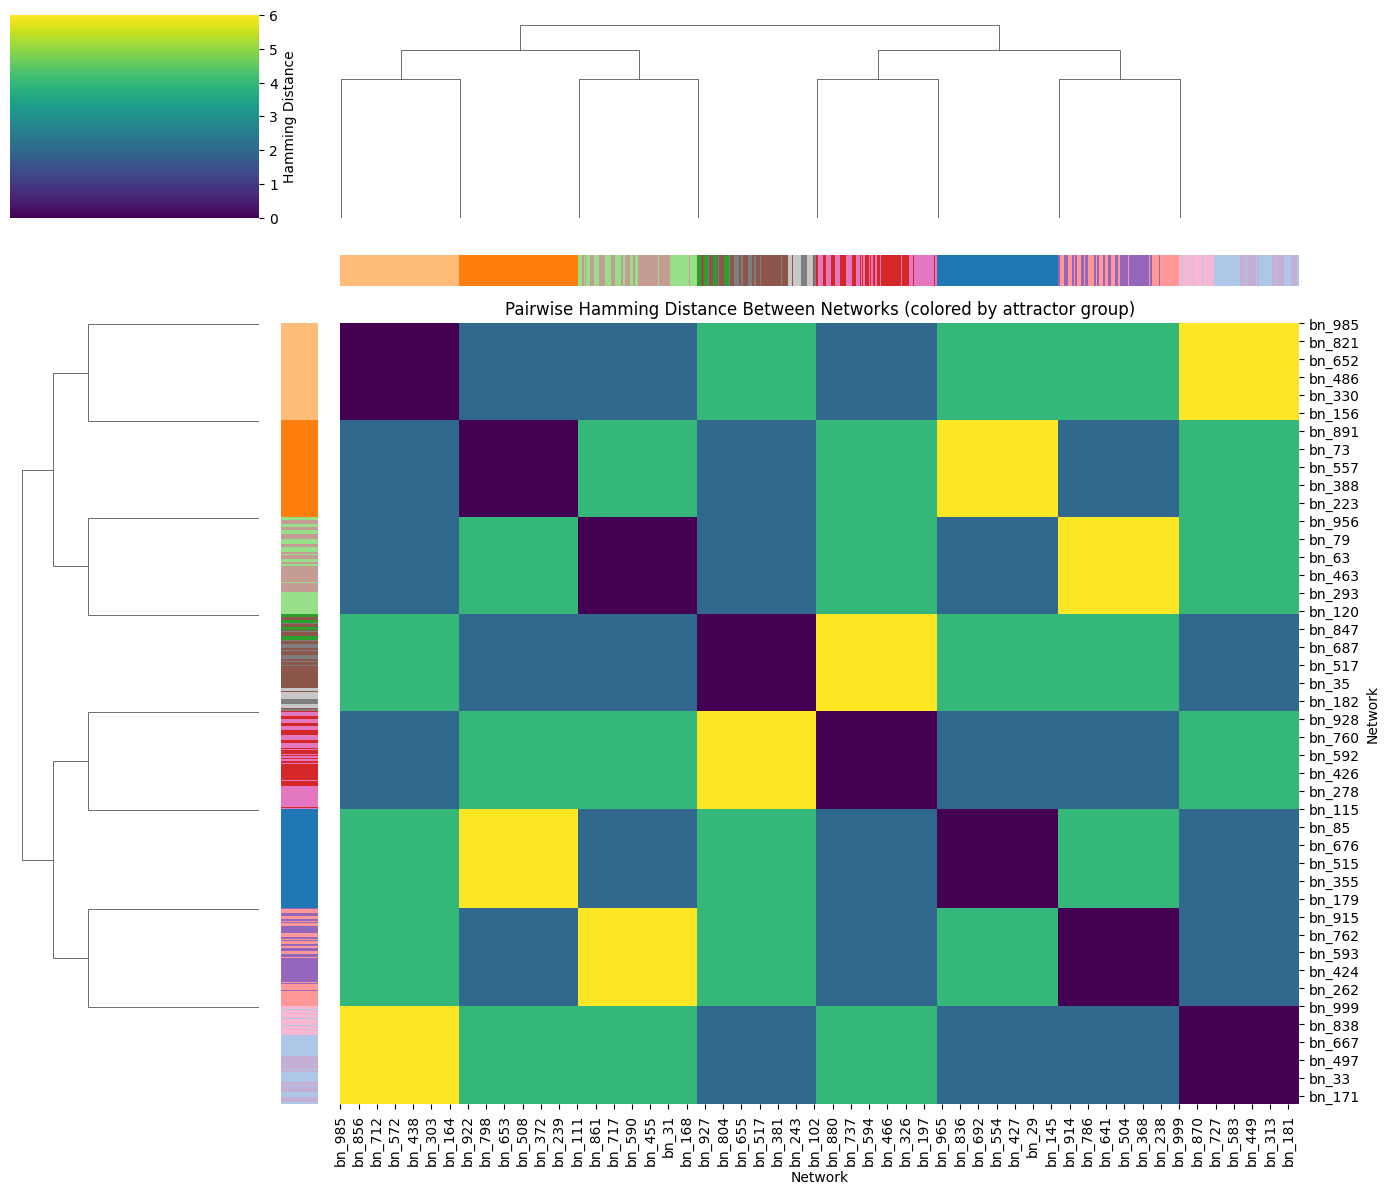

In [48]:
# Convert to DataFrame and create clustermap with attractor_group colors
df_hamming_series = pd.DataFrame(
    D_hamming_series,
    index=[Path(f).stem for f in network_series.filenames],
    columns=[Path(f).stem for f in network_series.filenames]
)

# Prepare row and column colors based on attractor_group
# Create a color mapping for each unique group
unique_groups = attractor_group.iloc[:, 0].unique()
colors = plt.cm.tab20(range(len(unique_groups)))
group_color_map = {group: colors[i] for i, group in enumerate(unique_groups)}

# Create row and column color vectors
row_colors = [group_color_map[attractor_group.loc[idx, attractor_group.columns[0]]] 
              for idx in df_hamming_series.index if idx in attractor_group.index]
col_colors = row_colors  # Same colors for columns since it's symmetric

# Create clustermap visualization with attractor_group colors
g = sns.clustermap(df_hamming_series, cmap='viridis', annot=False, 
                   cbar_kws={'label': 'Hamming Distance'},
                   row_colors=row_colors, col_colors=col_colors,
                   figsize=(14, 12))
g.ax_heatmap.set_title('Pairwise Hamming Distance Between Networks (colored by attractor group)')
g.ax_heatmap.set_xlabel('Network')
g.ax_heatmap.set_ylabel('Network')
plt.tight_layout()
plt.show()
